In [35]:
import numpy as np
import random

In [36]:
with open('text8') as f:
    corpus = f.read()[:10000].split()

In [281]:
len(corpus)

1603

In [38]:
vocab = set(corpus)

len(vocab)

628

In [39]:
word2i = {w: idx for idx, w in enumerate(vocab)}
i2word = {idx: w for idx, w in enumerate(vocab)}

In [40]:
word2i

{'general': 0,
 'they': 1,
 'periodical': 2,
 'no': 3,
 'often': 4,
 'co': 5,
 'unnecessary': 6,
 'associations': 7,
 'revolutionary': 8,
 'whoever': 9,
 'profits': 10,
 'december': 11,
 'other': 12,
 'concerning': 13,
 'respected': 14,
 'twenty': 15,
 'aid': 16,
 'offer': 17,
 'figure': 18,
 'commonly': 19,
 'doctrine': 20,
 'lahontan': 21,
 'him': 22,
 'described': 23,
 'mind': 24,
 'leading': 25,
 'term': 26,
 'he': 27,
 'join': 28,
 'class': 29,
 'moved': 30,
 'thing': 31,
 'democratic': 32,
 'but': 33,
 'found': 34,
 'at': 35,
 'structures': 36,
 'elements': 37,
 'exchange': 38,
 'joined': 39,
 'institution': 40,
 'autonomous': 41,
 'unite': 42,
 'failed': 43,
 'gained': 44,
 'for': 45,
 'based': 46,
 'way': 47,
 'relations': 48,
 'division': 49,
 'known': 50,
 'about': 51,
 'hague': 52,
 'while': 53,
 'major': 54,
 'strategy': 55,
 'did': 56,
 'movements': 57,
 'early': 58,
 'stoic': 59,
 'genuine': 60,
 'argue': 61,
 'communists': 62,
 'thought': 63,
 'brought': 64,
 'most': 65,

In [41]:
i2word

{0: 'general',
 1: 'they',
 2: 'periodical',
 3: 'no',
 4: 'often',
 5: 'co',
 6: 'unnecessary',
 7: 'associations',
 8: 'revolutionary',
 9: 'whoever',
 10: 'profits',
 11: 'december',
 12: 'other',
 13: 'concerning',
 14: 'respected',
 15: 'twenty',
 16: 'aid',
 17: 'offer',
 18: 'figure',
 19: 'commonly',
 20: 'doctrine',
 21: 'lahontan',
 22: 'him',
 23: 'described',
 24: 'mind',
 25: 'leading',
 26: 'term',
 27: 'he',
 28: 'join',
 29: 'class',
 30: 'moved',
 31: 'thing',
 32: 'democratic',
 33: 'but',
 34: 'found',
 35: 'at',
 36: 'structures',
 37: 'elements',
 38: 'exchange',
 39: 'joined',
 40: 'institution',
 41: 'autonomous',
 42: 'unite',
 43: 'failed',
 44: 'gained',
 45: 'for',
 46: 'based',
 47: 'way',
 48: 'relations',
 49: 'division',
 50: 'known',
 51: 'about',
 52: 'hague',
 53: 'while',
 54: 'major',
 55: 'strategy',
 56: 'did',
 57: 'movements',
 58: 'early',
 59: 'stoic',
 60: 'genuine',
 61: 'argue',
 62: 'communists',
 63: 'thought',
 64: 'brought',
 65: 'most',

In [42]:
sum = 0
countOfWord = [sum+1 for w in corpus]

In [43]:
unigramFrequencies = {w: corpus.count(w) for w in vocab}

In [44]:
weightedUnigramFrequencies = {}

In [45]:
for k, v in unigramFrequencies.items():
    weightedUnigramFrequencies[k] = (v ** 0.75) / (len(vocab) ** 0.75)

In [46]:
weightedUnigramFrequencies

{'general': 0.013406109549120714,
 'they': 0.026653716277650365,
 'periodical': 0.013406109549120714,
 'no': 0.018170681173797824,
 'often': 0.007971320430160137,
 'co': 0.007971320430160137,
 'unnecessary': 0.007971320430160137,
 'associations': 0.007971320430160137,
 'revolutionary': 0.007971320430160137,
 'whoever': 0.007971320430160137,
 'profits': 0.007971320430160137,
 'december': 0.007971320430160137,
 'other': 0.013406109549120714,
 'concerning': 0.007971320430160137,
 'respected': 0.007971320430160137,
 'twenty': 0.007971320430160137,
 'aid': 0.007971320430160137,
 'offer': 0.007971320430160137,
 'figure': 0.007971320430160137,
 'commonly': 0.013406109549120714,
 'doctrine': 0.007971320430160137,
 'lahontan': 0.007971320430160137,
 'him': 0.013406109549120714,
 'described': 0.007971320430160137,
 'mind': 0.007971320430160137,
 'leading': 0.007971320430160137,
 'term': 0.026653716277650365,
 'he': 0.04814761521294231,
 'join': 0.007971320430160137,
 'class': 0.01817068117379782

In [47]:
def sigmoid(m):
  return (1 / (1 + np.e ** (-m)))

In [48]:
sigmoid(-1)

0.2689414213699951

In [49]:
# def backwardLoss(t, c, n, targetWordI, contextWordsI, negativeSamplesI, lr):
#     d = (np.mean(np.sum((c @ t.reshape(32, 3, 1)), 1)))
#     s = sigmoid(d)
#     posDer = (s - 1) * t
#     posLoss = np.log(s)
#     d = -(np.mean(np.sum((n @ t.reshape(32, 3, 1)), 1)))
#     s = sigmoid(d)
#     negDer = s * t
#     negLoss = np.log(s)

#     #backprop
#     print('c from backwardLoss func reshaped removed zeros', c.reshape(128, 3)[~np.all(c.reshape(128, 3)==0, axis=1)].shape)
#     print('sigmoid partPosDer from backwardLoss', sigmoid(c @ t.reshape(32, 3, 1)))
#     partPosDer = (sigmoid(c @ t.reshape(32, 3, 1)) - 1)
#     partPosDer.reshape(128, 1)[np.all(partPosDer.reshape(128, 1)==-0.5, axis=1)] = \
#         np.repeat([[0]], partPosDer.reshape(128, 1)[np.all(partPosDer.reshape(128, 1)==-0.5, axis=1)].shape[0], axis=0)
#     print('part pos der finding',partPosDer)
#     print('full part pos der', (lr * partPosDer * t.reshape(32, 1, 3)).reshape(128, 3))
#     C[contextWordsI] -= (lr * partPosDer * t.reshape(32, 1, 3)).reshape(128, 3)
#     partNegDer = sigmoid(n @ t.reshape(32, 3, 1))
#     C[negativeSamplesI] -= (lr * partNegDer * t.reshape(32, 1, 3)).reshape(256, 3)
#     W[targetWordI] -= lr * ((partPosDer.reshape(32, 1, 4) @ c).squeeze(axis=1) + (partNegDer.reshape(32, 1, 8) @ n).squeeze(axis=1))

#     return -(posLoss + negLoss)

In [ ]:
# d = c @ t.reshape(32, dim_size, 1)
# print(d.shape)
# s = sigmoid(d)
# print(s.shape)
# posLoss = np.mean(np.log(s))

# print(posLoss)

(32, 4, 1)
(32, 4, 1)
-1.3003442738249096


In [ ]:
# import numpy as np

# # Example: shape (32, 4, 3)
# x = np.zeros((32, 4, 3))
# x[5, 1, 2] = 7   # row 5 is not all zero anymore

# # True for rows where all entries are 0
# mask = np.all(x == 0, axis=(1, 2))

# # Indices of those rows
# rows_with_all_zeros = np.nonzero(mask)[0]

# print(x)
# print(rows_with_all_zeros)

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 7.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  

In [ ]:
# def backwardLoss(t, c, n, targetWordI, contextWordsI, negativeSamplesI, lr, dim_size):
#     c_flat = c.reshape(-1, c.shape[2])
#     mask = np.all(c_flat == 0, axis=1)  # shape: (32,)
#     c_rows_with_all_zeros = np.nonzero(mask)[0]
#     n_flat = n.reshape(-1, n.shape[2])
#     mask = np.all(n_flat == 0, axis=1)  # shape: (32,)
#     n_rows_with_all_zeros = np.nonzero(mask)[0]
    
    
#     d = c @ t.reshape(32, dim_size, 1)
#     s = sigmoid(d)
#     partPosDer = (s - 1) * t.reshape(32, 1, dim_size)
#     posLoss = np.mean(np.log(s))
#     d = -n @ t.reshape(32, dim_size, 1)
#     s = sigmoid(d)
#     partNegDer = s * t.reshape(32, 1, dim_size)
#     negLoss = np.mean(np.log(s))
#     # print(f"part pos der, part neg der: {partPosDer}, {partNegDer}")
#     #backprop
#     C[contextWordsI] -= (lr * np.delete(partPosDer.reshape(-1, partPosDer.shape[2]), c_rows_with_all_zeros, axis=0))
#     C[negativeSamplesI] -= (lr * np.delete(partNegDer.reshape(-1, partNegDer.shape[2]), n_rows_with_all_zeros, axis=0))
#     W[targetWordI] -= (lr * ())
    
#     # c_flatten = c.reshape(128, dim_size)[~np.all(c.reshape(128, dim_size) == 0.0, axis=1)]
#     # partPosDer = sigmoid(c_flatten @ t.reshape(dim_size, 32)) - 1
#     # PosDer = (partPosDer @ t.reshape(32, dim_size)) * lr
#     # C[contextWordsI] -= PosDer
#     # n_flatten = n.reshape(256, dim_size)[~np.all(n.reshape(256, dim_size) == 0.0, axis=1)]
#     # partNegDer = sigmoid(n_flatten @ t.reshape(dim_size, 32))
#     # NegDer = (partNegDer @ t.reshape(32, dim_size)) * lr
#     # C[negativeSamplesI] -= NegDer
#     # W[targetWordI] -= (lr * ((partPosDer.T @ c_flatten) + (partNegDer.T @ n_flatten)))

#     return -(posLoss + negLoss)


In [ ]:
# WINDOW_SIZE = 2
# K = 2
# words = list(weightedUnigramFrequencies.keys())
# weights = list(weightedUnigramFrequencies.values())

# def SGNS(choices, dim_size):
#     targetWord = []
#     contextWordsM = []
#     negativeSamplesM = []
#     targetWordI = []
#     contextWordsI = []
#     negativeSamplesI = []
#     for idx in choices:
#         contextWordsPadded = np.zeros((4, dim_size))
#         negativeSamplesPadded  = np.zeros((8, dim_size))
#         targetWordI += [word2i[corpus[idx]]]

        
#         targetWord.append(W[word2i[corpus[idx]]])
#         contextWords = corpus[max(idx-WINDOW_SIZE, 0):max(idx, 0)] \
#                                 + corpus[idx+1:idx+WINDOW_SIZE+1]
#         sliceRange = C[[word2i[w] for w in contextWords]].shape[0]
#         contextWordsPadded[:sliceRange] = C[[word2i[w] for w in contextWords]]
#         contextWordsM.append(contextWordsPadded)
#         contextWordsI += [word2i[w] for w in contextWords]
#         negativeSamples = random.choices(words, weights=weights, \
#                                          k=len(contextWords)*K)
#         sliceRange = C[[word2i[w] for w in negativeSamples]].shape[0]
#         negativeSamplesPadded[:sliceRange] = C[[word2i[w] for w in negativeSamples]]
#         negativeSamplesM.append(negativeSamplesPadded)
#         negativeSamplesI += [word2i[w] for w in negativeSamples]
#     targetWord = np.stack(targetWord, axis=0)
#     contextWordsM = np.stack(contextWordsM, axis=0)
#     negativeSamplesM = np.stack(negativeSamplesM, axis=0)
    

#     return targetWord, contextWordsM, negativeSamplesM, targetWordI, contextWordsI, negativeSamplesI


In [ ]:
# EPOCHS = 100
# ITERS = int(len(corpus) / 32)
# WINDOW_SIZE = 2
# K = 2
# dim_size = 100
# words = list(weightedUnigramFrequencies.keys())
# weights = list(weightedUnigramFrequencies.values())
# C = np.random.randn(len(vocab), dim_size)
# W = np.random.randn(len(vocab), dim_size)
# lr = 1e-6
# total_loss = 0.0

# for e in range(EPOCHS):
#   total_loss = 0.0
#   for i in range(ITERS):
#     choices = np.random.choice(np.arange(len(corpus)), 32)
#     t, c, n, tI, cI, nI = SGNS(choices, dim_size)
#     L = backwardLoss(t, c, n, tI, cI, nI, lr, dim_size=dim_size)
#     total_loss += L
#   print(f'Epoch: {e+1} {total_loss/ITERS}')


Epoch: 1 7.880647932344797
Epoch: 2 8.201432372792102
Epoch: 3 7.856378454638767
Epoch: 4 7.957129350127257
Epoch: 5 7.924450824960408
Epoch: 6 7.8644214914785575
Epoch: 7 7.948812853979243
Epoch: 8 7.888531914532726
Epoch: 9 7.8736366122770765
Epoch: 10 7.922319709373338
Epoch: 11 8.05967498362149
Epoch: 12 8.065509593096236
Epoch: 13 7.772321935320768
Epoch: 14 8.004490142610319
Epoch: 15 8.075096080788795
Epoch: 16 7.832106156639998
Epoch: 17 8.098908761719695
Epoch: 18 8.061500977983515
Epoch: 19 8.136877468939025
Epoch: 20 8.075251754375952
Epoch: 21 7.926128955041215
Epoch: 22 8.172778728820974
Epoch: 23 7.9522007416524225
Epoch: 24 7.919110235305528
Epoch: 25 8.072299062906373
Epoch: 26 8.059044419519676
Epoch: 27 7.953450803806565
Epoch: 28 8.033728169995975
Epoch: 29 7.949279798612127
Epoch: 30 7.997954594742336
Epoch: 31 7.931723048780756
Epoch: 32 8.133712297078967
Epoch: 33 7.987564983035545
Epoch: 34 7.939455228407075
Epoch: 35 7.960904193104121
Epoch: 36 8.084900989986805

In [ ]:
WINDOW_SIZE = 2
K = 4
dim_size = 100
C = np.random.randn(len(vocab), dim_size)
W = np.random.randn(len(vocab), dim_size)
words = list(weightedUnigramFrequencies.keys())
weights = list(weightedUnigramFrequencies.values())
lr = 1e-3
running_loss = []

for i in range(10000):
    total_loss = 0.0
    for i, w in enumerate(corpus):
        #get target, context, negative samples
        t = w
        c = corpus[max(i-WINDOW_SIZE, 0):max(i, 0)] \
                                    + corpus[i+1:i+WINDOW_SIZE+1]
        n = random.choices(words, weights=weights, \
                                            k=len(c)*K)
        
        #get target, context, negative samples indices    
        tI = word2i[t]
        cI = [word2i[cw] for cw in c]
        nI = [word2i[nw] for nw in n]

        #get target, context, negaIve samples embeddings
        tE = W[tI]
        cE = C[cI]
        nE = C[nI]

        #calculate total loss
        pL = np.sum(np.log(sigmoid(cE @ tE)))
        nL = np.sum(np.log(sigmoid(-nE @ tE)))
        L = -(pL + nL)
        total_loss += L

        #derivaIve calculaIon
        lParDerC = (sigmoid(cE @ tE) - 1)
        lParDerN = (sigmoid(nE @ tE))
        lParDerT = np.sum(lParDerC[:, None] * cE, 0) + np.sum(lParDerN[:, None] * nE, 0)
        
        #backprop
        C[cI] -= lr * lParDerC[:, None] * tE
        C[nI] -= lr * lParDerN[:, None] * tE
        W[tI] -= lr * lParDerT
    running_loss.append(total_loss/len(corpus))
    print(f"Epoch Loss: {total_loss/len(corpus)}")

Epoch Loss: 47.5165172542221
Epoch Loss: 46.089363735849474
Epoch Loss: 45.34834291196409
Epoch Loss: 43.49655761344468
Epoch Loss: 43.47369753358333
Epoch Loss: 42.07067178649112
Epoch Loss: 41.37049747294545
Epoch Loss: 40.34822266531388
Epoch Loss: 39.095130232017844
Epoch Loss: 39.29744454691159
Epoch Loss: 37.888717193834005
Epoch Loss: 37.93964546230715
Epoch Loss: 37.454143105188926
Epoch Loss: 35.47999757128148
Epoch Loss: 35.2979102185456
Epoch Loss: 35.202601667531226
Epoch Loss: 34.638248516810734
Epoch Loss: 34.0849253544487
Epoch Loss: 33.63089585329082
Epoch Loss: 33.492719979724214
Epoch Loss: 32.83088968203747
Epoch Loss: 32.67914929811401
Epoch Loss: 32.26511196207374
Epoch Loss: 31.158614943857504
Epoch Loss: 30.759016305384268
Epoch Loss: 31.20172115242747
Epoch Loss: 30.6328420908053
Epoch Loss: 29.876525428078264
Epoch Loss: 29.91672826296548
Epoch Loss: 28.917097266383333
Epoch Loss: 29.786150114937996
Epoch Loss: 28.539505806476466
Epoch Loss: 28.512631776019948


KeyboardInterrupt: 

In [212]:
print(tE.shape, cE.shape, nE.shape, pL, nL, L, lParDerC.shape, lParDerN.shape, lParDerT.shape)

(3,) (4, 3) (8, 3) -4.4882266195282785 -7.4981986508472325 11.986425270375511 (4,) (8,) (3,)


In [206]:
lParDerC[:, :, None].shape

(4, 3, 1)

In [221]:
len(corpus)

1603

In [ ]:
word2i

{'general': 0,
 'they': 1,
 'periodical': 2,
 'no': 3,
 'often': 4,
 'co': 5,
 'unnecessary': 6,
 'associations': 7,
 'revolutionary': 8,
 'whoever': 9,
 'profits': 10,
 'december': 11,
 'other': 12,
 'concerning': 13,
 'respected': 14,
 'twenty': 15,
 'aid': 16,
 'offer': 17,
 'figure': 18,
 'commonly': 19,
 'doctrine': 20,
 'lahontan': 21,
 'him': 22,
 'described': 23,
 'mind': 24,
 'leading': 25,
 'term': 26,
 'he': 27,
 'join': 28,
 'class': 29,
 'moved': 30,
 'thing': 31,
 'democratic': 32,
 'but': 33,
 'found': 34,
 'at': 35,
 'structures': 36,
 'elements': 37,
 'exchange': 38,
 'joined': 39,
 'institution': 40,
 'autonomous': 41,
 'unite': 42,
 'failed': 43,
 'gained': 44,
 'for': 45,
 'based': 46,
 'way': 47,
 'relations': 48,
 'division': 49,
 'known': 50,
 'about': 51,
 'hague': 52,
 'while': 53,
 'major': 54,
 'strategy': 55,
 'did': 56,
 'movements': 57,
 'early': 58,
 'stoic': 59,
 'genuine': 60,
 'argue': 61,
 'communists': 62,
 'thought': 63,
 'brought': 64,
 'most': 65,

In [311]:
embedding_matrix = C + W

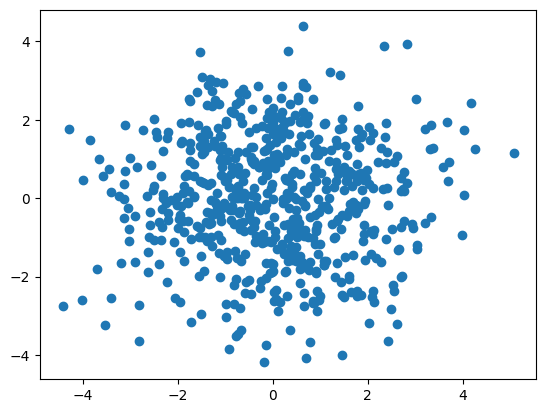

In [222]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(C + W)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
plt.show()


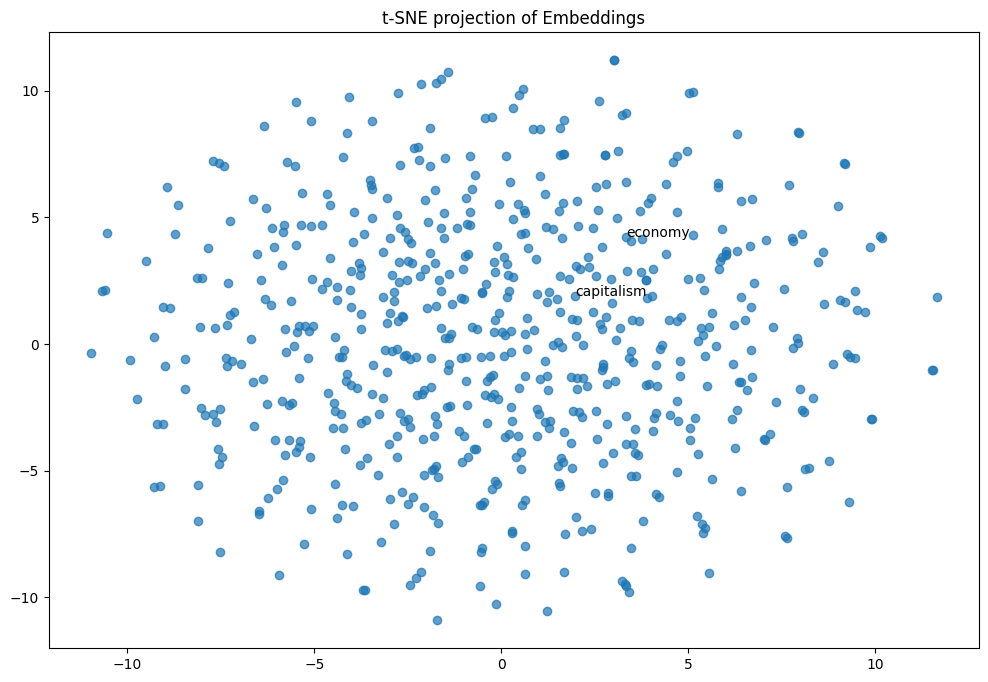

In [277]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Suppose `embeddings` is your matrix (600, 100)
# And `vocab` is a list of your 600 tokens
# embeddings = np.array(...)
# vocab = [...]

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(C + W)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7)

# Optional: annotate a few points
for i, word in enumerate(['economy', 'capitalism']):  # annotate only first 50 for clarity
    plt.annotate(word, (embeddings_2d[word2i[word], 0], embeddings_2d[word2i[word], 1]))

plt.title("t-SNE projection of Embeddings")
plt.show()


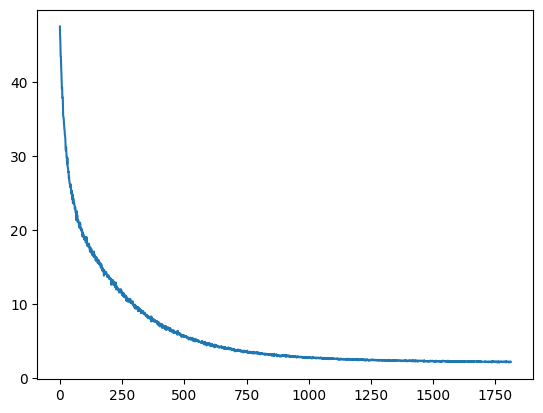

In [244]:
plt.plot(running_loss)

In [272]:
vocab

{'a',
 'abolished',
 'about',
 'abundance',
 'abuse',
 'accepted',
 'access',
 'accordance',
 'according',
 'accumulated',
 'accusation',
 'act',
 'active',
 'activity',
 'adopted',
 'advocate',
 'advocated',
 'after',
 'against',
 'agitation',
 'aid',
 'all',
 'also',
 'although',
 'am',
 'american',
 'amidst',
 'amoralism',
 'amount',
 'an',
 'anabaptists',
 'anarchism',
 'anarchist',
 'anarchiste',
 'anarchists',
 'anarchy',
 'ancestors',
 'ancient',
 'and',
 'andrews',
 'anomie',
 'answers',
 'anthropologists',
 'anti',
 'any',
 'april',
 'archons',
 'are',
 'argue',
 'argued',
 'armand',
 'around',
 'arrive',
 'as',
 'assert',
 'associating',
 'association',
 'associations',
 'at',
 'attitudes',
 'august',
 'authoritarian',
 'autonomous',
 'away',
 'b',
 'bad',
 'bakunin',
 'bands',
 'bank',
 'banking',
 'baron',
 'based',
 'be',
 'became',
 'been',
 'before',
 'being',
 'belief',
 'believe',
 'believed',
 'believing',
 'belongs',
 'benjamin',
 'bertrand',
 'between',
 'blamed',
 

In [260]:
word2i['economy']

584

In [263]:
word2i['peter']

569

In [264]:
embeddings_2d[569]

array([-1.7703631,  6.099096 ], dtype=float32)

In [307]:
scores = (embedding_matrix @ embedding_matrix[word2i['king']])

In [308]:
top10_idx = np.argsort(scores)[::-1][:10]  # indices of top 10 values
top10_vals = scores[top10_idx]

In [309]:
top10_idx

array([ 98, 326,  88, 331, 477, 426,  81, 250, 227,  17])

In [310]:
for idx in top10_idx:
  print(i2word[idx])

king
ruler
regarded
chief
take
will
moment
writes
inclined
offer


In [312]:
def top_nearest_words(source_word: str, num: int):
  nearest_words = []
  scores = (embedding_matrix @ embedding_matrix[word2i[source_word]])
  top_idx = np.argsort(scores)[::-1][:num]  # indices of top 10 values
  top_vals = scores[top_idx]
  for idx in top_idx:
    nearest_words.append(i2word[idx])
  return nearest_words
  

In [315]:
top_nearest_words('king', 20)

['king',
 'ruler',
 'regarded',
 'chief',
 'take',
 'will',
 'moment',
 'writes',
 'inclined',
 'offer',
 'profits',
 'work',
 'succeeding',
 'experiment',
 'before',
 'competition',
 'by',
 'vary',
 'within',
 'fought']